In [31]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import json
import seaborn as sns
import geopandas as gpd

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Desempeño en Santiago (Validación):
MAE:  0.39 MWh (Error promedio por hora)
RMSE: 0.61 MWh


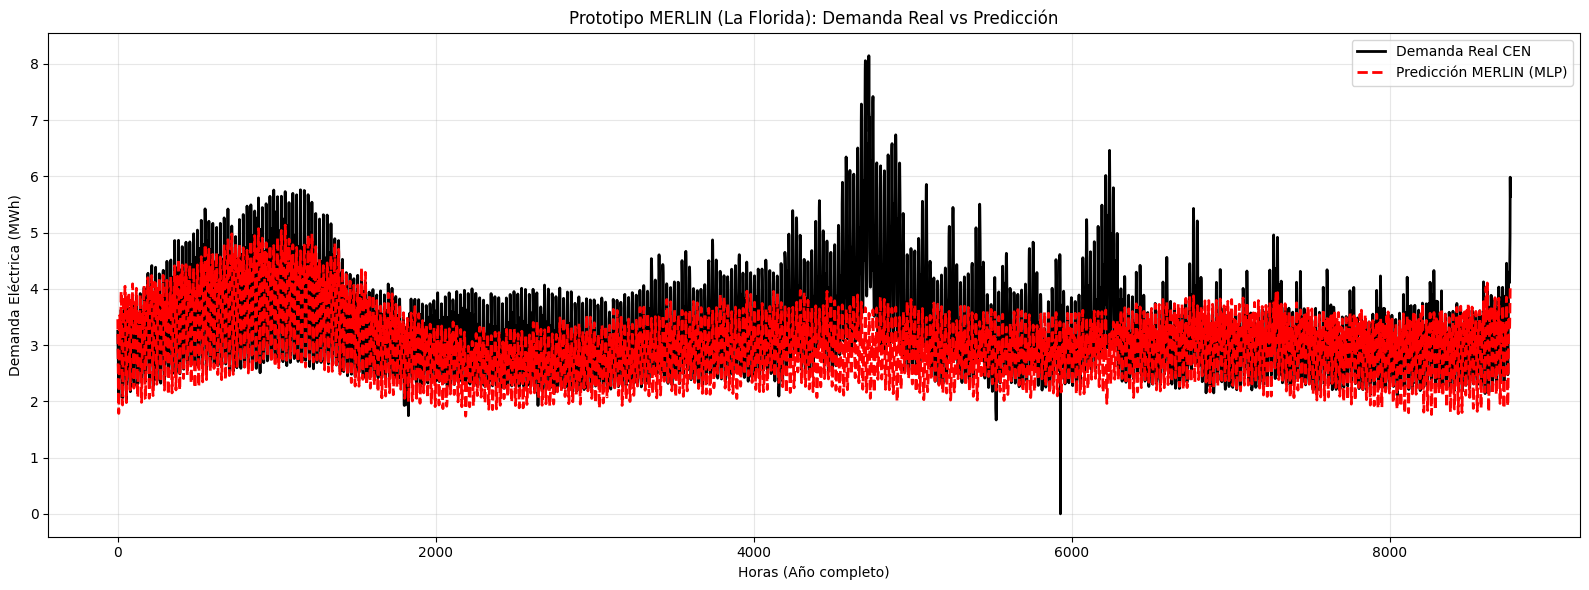

In [ ]:

# 1. Cargar el dataframe con los resultados del modelo 
model = tf.keras.models.load_model('../models/modelo_nacional/ml_models/best_mlp_ALGARROBO.keras')
scaler_y = joblib.load('../models/modelo_nacional/scaler/scaler_demand_ALGARROBO.pkl')

# 2. Cargar datos de Validación (o Test)
df_val = pd.read_parquet("../data/processed/modelo_nacional/ml_data/val_ALGARROBO.parquet")
y_val_scaled = df_val['demanda_mwh'].values
X_val_scaled = df_val.drop(columns=['demanda_mwh']).values

# 3. Hacer predicciones (el resultado es un valor entre 0 y 1)
y_pred_scaled = model.predict(X_val_scaled)

# 4. DEVOLVER A ESCALA ORIGINAL (MWh)
# Transformamos la matriz (N, ) a (N, 1) porque scikit-learn lo exige
y_val_real = scaler_y.inverse_transform(y_val_scaled.reshape(-1, 1)).flatten()
y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 5. Calcular Métricas de Desempeño
mae = mean_absolute_error(y_val_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
print(f"Desempeño en Santiago (Validación):")
print(f"MAE:  {mae:.2f} MWh (Error promedio por hora)")
print(f"RMSE: {rmse:.2f} MWh")

# 6. Gráfico de Verificación Fina (Visualizar 1 semana de Invierno)
# Supongamos que queremos ver las primeras 168 horas (1 semana)
inicio = 0 # Un punto arbitrario (ej. a mitad de año)
fin = 8760

plt.figure(figsize=(16, 6))
plt.plot(y_val_real[inicio:fin], label='Demanda Real CEN', color='black', linewidth=2)
plt.plot(y_pred_real[inicio:fin], label='Predicción MERLIN (MLP)', color='red', linestyle='--', linewidth=2)

plt.title('Prototipo MERLIN (La Florida): Demanda Real vs Predicción')
plt.xlabel('Horas (Año completo)')
plt.ylabel('Demanda Eléctrica (MWh)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# 1. Cargar dataframe con los resultados del modelo 
RESULTADOS_DIR = "../models/modelo_nacional/results"
df_resultados = pd.read_parquet(RESULTADOS_DIR + "/resultados_modelo_nacional.parquet")

# ==========================================
# 2. DESEMPEÑO A NIVEL NACIONAL (Serie Agregada)
# ==========================================
# Sumamos todas las comunas en una misma hora para obtener la curva del país completo
df_serie_nacional = df_resultados.groupby('fecha_hora')[['demanda_real_mwh', 'demanda_pred_mwh']].sum().reset_index()

y_real_nac = df_serie_nacional["demanda_real_mwh"].values
y_pred_nac = df_serie_nacional["demanda_pred_mwh"].values

mae_nacional = mean_absolute_error(y_real_nac, y_pred_nac)
rmse_nacional = np.sqrt(mean_squared_error(y_real_nac, y_pred_nac))
total_nacional_real = y_real_nac.sum() / 1e6 # a TWh 
total_nacional_pred = y_pred_nac.sum() / 1e6 # a TWh
nRMSE_nacional = rmse_nacional / y_real_nac.mean()

print(f"--- Desempeño a nivel Nacional (Serie Total Agregada):")
print(f"MAE:  {mae_nacional:.2f} MWh (Error promedio por hora en todo el país)")
print(f"nRMSE: {nRMSE_nacional:.2f} -\n")

# ==========================================
# 3. DESEMPEÑO A NIVEL REGIONAL
# ==========================================
# CORRECCIÓN: Agrupamos por fecha_hora Y por region
df_serie_regional = df_resultados.groupby(['fecha_hora', 'region'])[['demanda_real_mwh', 'demanda_pred_mwh']].sum().reset_index()
df_serie_regional = df_serie_regional.sort_values(['region', 'fecha_hora']).reset_index(drop=True)

# Métrica global a escala regional
y_real_reg = df_serie_regional["demanda_real_mwh"].values
y_pred_reg = df_serie_regional["demanda_pred_mwh"].values
print(f"--- Desempeño Global a nivel Regional:")
print(f"MAE Global: {mean_absolute_error(y_real_reg, y_pred_reg):.2f} MWh\n")

# Desglose de métricas por CADA región
print("Métricas desglosadas por Región:")
metricas_reg = []
for region, df_reg in df_serie_regional.groupby('region'):
    mae = mean_absolute_error(df_reg['demanda_real_mwh'], df_reg['demanda_pred_mwh'])
    rmse = np.sqrt(mean_squared_error(df_reg['demanda_real_mwh'], df_reg['demanda_pred_mwh']))
    total_regional_real = df_reg['demanda_real_mwh'].values.sum()
    total_regional_pred = df_reg['demanda_pred_mwh'].values.sum()
    avg_regional_real = df_reg['demanda_real_mwh'].values.mean()
    metricas_reg.append({
        'Region': region, 
        'MAE': mae, 
        'RMSE': rmse, 
        'nRMSE': 100 * rmse/avg_regional_real, 
        'total_real_twh': total_regional_real / 1e6, 
        'total_pred_twh': total_regional_pred / 1e6
        })

df_metricas_regionales = pd.DataFrame(metricas_reg)
print(df_metricas_regionales.to_string(index=False))
print("\n")

# ==========================================
# 4. DESEMPEÑO A NIVEL COMUNAL
# ==========================================
# Los datos base ya tienen la resolución comunal/horaria, no hay que sumar nada.
print(f"--- Desempeño Global a nivel Comunal:")
y_real_com = df_resultados["demanda_real_mwh"].values
y_pred_com = df_resultados["demanda_pred_mwh"].values
print(f"MAE Global: {mean_absolute_error(y_real_com, y_pred_com):.2f} MWh\n")

# Desglose de métricas por CADA comuna
metricas_com = []
for comuna, df_com in df_resultados.groupby('comuna'):
    mae = mean_absolute_error(df_com['demanda_real_mwh'], df_com['demanda_pred_mwh'])
    rmse = np.sqrt(mean_squared_error(df_com['demanda_real_mwh'], df_com['demanda_pred_mwh']))
    total_comunal_real = df_com['demanda_real_mwh'].values.sum()
    total_comunal_pred = df_com['demanda_pred_mwh'].values.sum()
    avg_comunal_real = df_com['demanda_real_mwh'].values.mean()
    metricas_com.append({
        'comuna': comuna, 
        'MAE': mae, 
        'RMSE': rmse, 
        'nRMSE': 100 * rmse/avg_comunal_real, 
        'total_real_twh': total_comunal_real / 1e6, 
        'total_pred_twh': total_comunal_pred / 1e6 
        })

df_metricas_comunales = pd.DataFrame(metricas_com)

# Ordenamos para visualizar fácilmente las comunas con mejor/peor desempeño
df_metricas_comunales = df_metricas_comunales.sort_values(by='MAE').reset_index(drop=True)

print("Top 5 Comunas con MENOR error (Mejores predicciones):")
print(df_metricas_comunales.head())
print("\nTop 5 Comunas con MAYOR error (Para revisar/mejorar):")
print(df_metricas_comunales.tail())

--- Desempeño a nivel Nacional (Serie Total Agregada):
MAE:  391.32 MWh (Error promedio por hora en todo el país)
nRMSE: 0.06 -

--- Desempeño Global a nivel Regional:
MAE Global: 37.07 MWh

Métricas desglosadas por Región:
                               Region        MAE       RMSE     nRMSE  total_real_twh  total_pred_twh
                          ANTOFAGASTA 103.514882 128.338070  6.440454       17.455934       16.926834
                   ARICA Y PARINACOTA   2.346308   3.130280  6.488429        0.422618        0.410584
                              ATACAMA  39.079863  46.441878 10.396948        3.912984        3.778843
                               BIOBÍO  27.609729  35.136458  6.679039        4.608378        4.487823
                             COQUIMBO  15.361295  20.324850  8.750341        2.034728        1.968170
                         LA ARAUCANÍA  12.172161  15.795569  8.112915        1.705542        1.621587
LIBERTADOR GENERAL BERNARDO O'HIGGINS  36.612671  47.961596  8

In [18]:
# ==========================================
# 1. PREPARAR DATOS DEL BALANCE REGIONAL (BRE)
# ==========================================
# Cargar BRE y filtrar solo el año de validación (2021)
data_bre = pd.read_csv("../data/raw/wp2_elec_input_sector_shares_raw.csv")
df_bre_2021 = data_bre[data_bre['año'] == 2021].copy()

# Pivotear
df_sec = df_bre_2021.pivot_table(
    index='región', 
    columns='sector', 
    values='valor', 
    aggfunc='sum'
).reset_index()

# Calcular el total de la BRE (TWh). Suponiendo que 'valor' está en GWh, se divide por 1e3
sectores = ['Industrial', 'Residencial', 'Comercial', 'Público', 'Transporte']
sectores_presentes = [s for s in sectores if s in df_sec.columns] # Evita errores si falta algún sector
df_sec['total_BRE_TWh'] = df_sec[sectores_presentes].sum(axis=1) / 1e3

# ==========================================
# 2. PREPARAR TUS DATOS DEL MODELO
# ==========================================
# Agrupar la suma anual por región de tus resultados horarios
df_anual_modelo = df_resultados.groupby('region')[['demanda_real_mwh', 'demanda_pred_mwh']].sum().reset_index()

# Convertir MWh a TWh (dividiendo por 1 millón)
df_anual_modelo['total_real_CEN_TWh'] = df_anual_modelo['demanda_real_mwh'] / 1e6
df_anual_modelo['total_pred_TWh'] = df_anual_modelo['demanda_pred_mwh'] / 1e6

# ==========================================
# 3. EL CRUCE (MERGE) Y CÁLCULO DE ERRORES
# ==========================================
# Cargar el diccionario de alias
with open("../data/raw/reg_alias.json", 'r', encoding='utf-8') as f:
    reg_alias = json.load(f)

# Aplicar el diccionario para crear una columna común de cruce en tus datos del modelo
df_anual_modelo['region_BRE'] = df_anual_modelo['region'].map(reg_alias)

# Cruzar las tablas usando la llave común (region_BRE en el modelo == región en la BRE)
df_validacion_bre = pd.merge(
    df_anual_modelo, 
    df_sec[['región', 'total_BRE_TWh']], 
    left_on='region_BRE', 
    right_on='región', 
    how='left'
)

# Calcular el Error Porcentual Absoluto (MAPE estático)
# 1. Qué tan lejos quedó el modelo de la BRE
df_validacion_bre['error_Modelo_vs_BRE_%'] = 100 * np.abs(df_validacion_bre['total_pred_TWh'] - df_validacion_bre['total_BRE_TWh']) / df_validacion_bre['total_BRE_TWh']

# 2. Qué tan lejos estaba el dato original del CEN respecto a la BRE (Desfase base)
df_validacion_bre['error_CEN_vs_BRE_%'] = 100 * np.abs(df_validacion_bre['total_real_CEN_TWh'] - df_validacion_bre['total_BRE_TWh']) / df_validacion_bre['total_BRE_TWh']

# Limpiar columnas redundantes y ordenar para visualizar
columnas_finales = ['region', 'total_BRE_TWh', 'total_real_CEN_TWh', 'total_pred_TWh', 'error_CEN_vs_BRE_%', 'error_Modelo_vs_BRE_%']
df_validacion_bre = df_validacion_bre[columnas_finales].sort_values(by='error_Modelo_vs_BRE_%')

# Agregar una fila de TOTAL NACIONAL
suma_bre = df_validacion_bre["total_BRE_TWh"].sum()
suma_cen = total_nacional_real
suma_pred = total_nacional_pred
error_cen_total = (np.abs(suma_cen - suma_bre)/suma_bre) * 100
error_modelo_total = (np.abs(suma_pred - suma_bre)/suma_bre) * 100
fila_total = {
    'region': 'TOTAL NACIONAL',  # O el nombre de tu columna de índice/región
    'total_BRE_TWh': suma_bre,
    'total_real_CEN_TWh': suma_cen,
    'total_pred_TWh': suma_pred,
    'error_CEN_vs_BRE_%': error_cen_total,
    'error_Modelo_vs_BRE_%': error_modelo_total
}
df_fila = pd.DataFrame([fila_total])
df_validacion_bre = pd.concat([df_validacion_bre, df_fila], ignore_index=True)

print("Resultados de Validación Anual frente al Balance Regional de Energía (2021):")
print(df_validacion_bre.to_string(index=False))

Resultados de Validación Anual frente al Balance Regional de Energía (2021):
                               region  total_BRE_TWh  total_real_CEN_TWh  total_pred_TWh  error_CEN_vs_BRE_%  error_Modelo_vs_BRE_%
LIBERTADOR GENERAL BERNARDO O'HIGGINS       4.765781            4.833909        4.650787            1.429539               2.412903
                          ANTOFAGASTA      17.456431           17.455934       16.926834            0.002848               3.033823
                                MAULE       2.831157            3.172226        2.961006           12.046973               4.586409
                             TARAPACÁ       2.213138            2.435457        2.469930           10.045423              11.603066
            METROPOLITANA DE SANTIAGO      23.585962           21.816263       20.625933            7.503186              12.549962
                              ATACAMA       3.237471            3.912984        3.778843           20.865450              16.722074

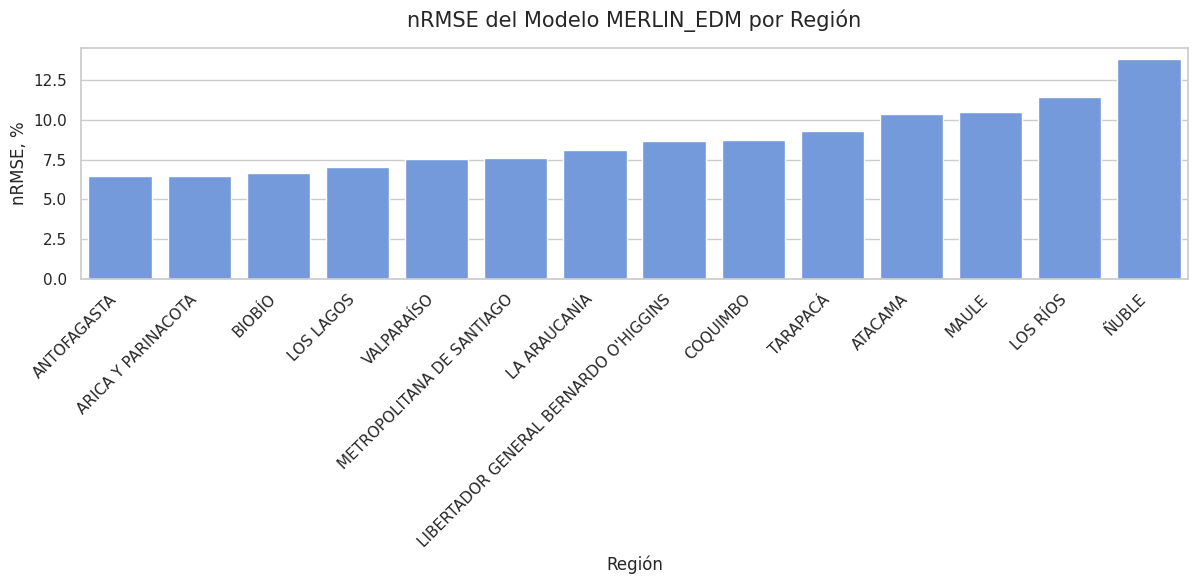

In [29]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Asumiendo que tu dataframe se llama df_metricas_regionales 
# y tiene las columnas 'region' y 'nRMSE'

plt.figure(figsize=(12, 6))
# Ordenar de menor a mayor error ayuda a la visualización
df_sorted = df_metricas_regionales.sort_values('nRMSE')

sns.barplot(data=df_sorted, x='Region', y='nRMSE', color='cornflowerblue')

plt.title('nRMSE del Modelo MERLIN_EDM por Región', fontsize=15, pad=15)
plt.xlabel('Región', fontsize=12)
plt.ylabel('nRMSE, %', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar las etiquetas para que no se superpongan
plt.tight_layout()
plt.show()

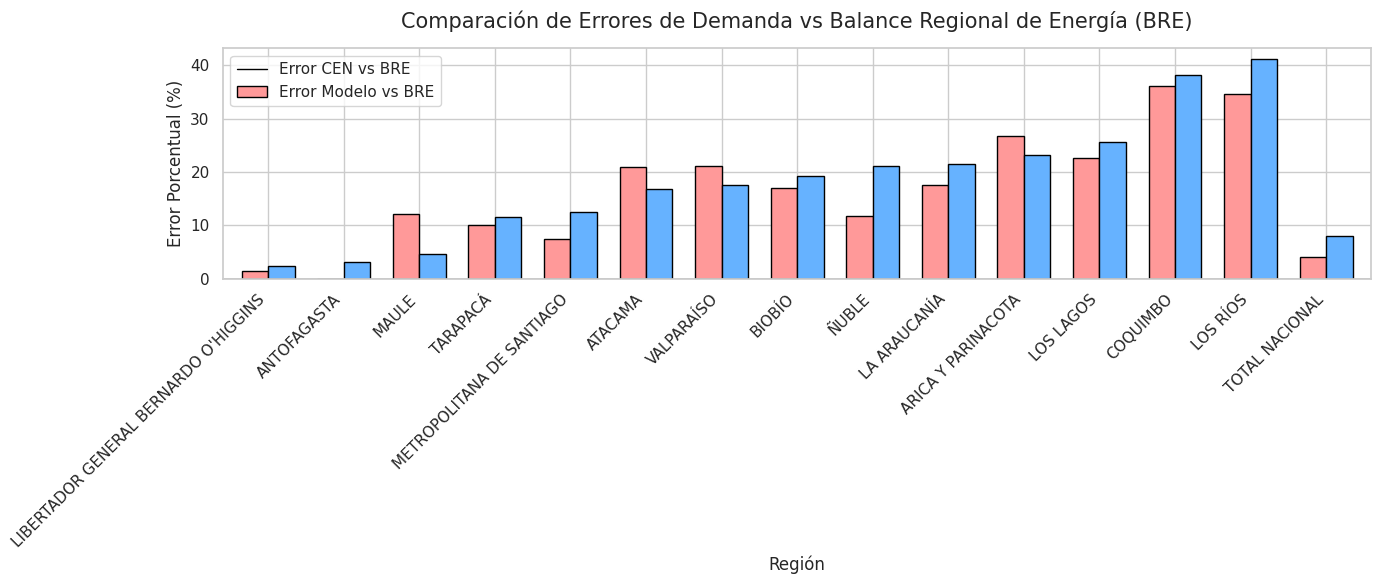

In [30]:
# Establecemos la región como índice para que pandas la use en el eje X
df_plot = df_validacion_bre.set_index('region')[['error_CEN_vs_BRE_%', 'error_Modelo_vs_BRE_%']]

# Graficar
ax = df_plot.plot(kind='bar', figsize=(14, 6), width=0.7, 
                  color=['#FF9999', '#66B2FF'], edgecolor='black')

plt.title('Comparación de Errores de Demanda vs Balance Regional de Energía (BRE)', fontsize=15, pad=15)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Error Porcentual (%)', fontsize=12)

# Añadir una línea horizontal en el 0 por si hay errores negativos (subestimación)
plt.axhline(0, color='black', linewidth=1)

# Mejorar la leyenda
plt.legend(['Error CEN vs BRE', 'Error Modelo vs BRE'], loc='best')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

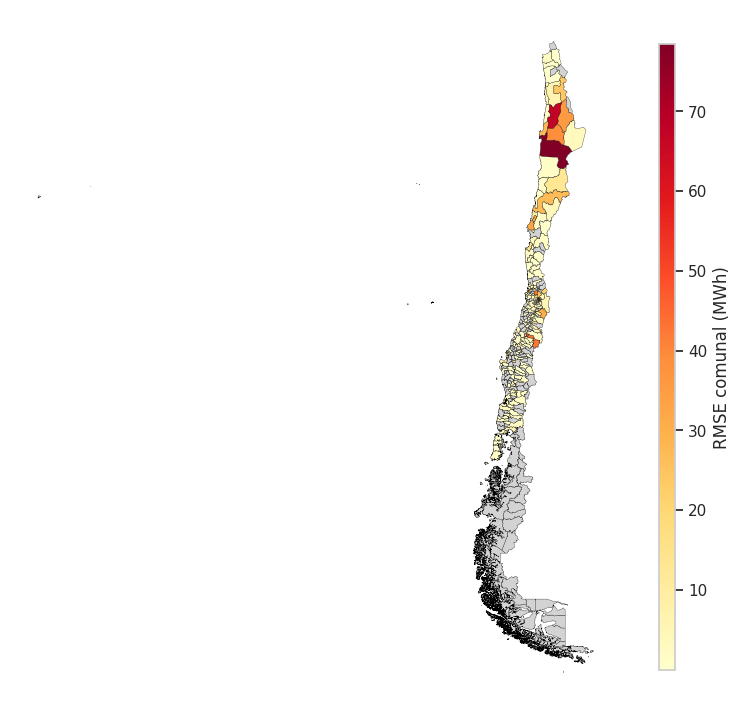

In [44]:
# 1. Cargar la capa geográfica de las comunas (que ya usaste antes en MERLIN)
gdf_comunas = gpd.read_file('../data/raw/capa_comunal.gpkg')

# 2. Unir (Merge) la geografía con tus resultados
# Asume que df_metricas_comunales tiene una columna 'comuna' con el nombre exacto o un código ID
gdf_mapa = gdf_comunas.merge(df_metricas_comunales, on='comuna', how='left')

# 3. Configurar la figura (Chile es largo, por lo que la figura debe ser alta)
fig, ax = plt.subplots(1, 1, figsize=(8, 16))

# 4. Graficar la geocapa (Choropleth)
gdf_mapa.plot(column='RMSE', 
              ax=ax, 
              legend=True,
              cmap='YlOrRd', 
              legend_kwds={
                  'label': "RMSE comunal (MWh)", 
                  'shrink': 0.4,   # Disminuye o aumenta la altura de la barra (ej: 0.5 a 0.8)
                  'aspect': 40,    # Controla el grosor de la barra (mayor número = más delgada)
                  'pad': 0.05,     # Controla la separación entre el mapa y la barra
                  'orientation': "vertical"
              },
              missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
              edgecolor='black',
              linewidth=0.2)

ax.set_axis_off() 
plt.tight_layout()
plt.show()

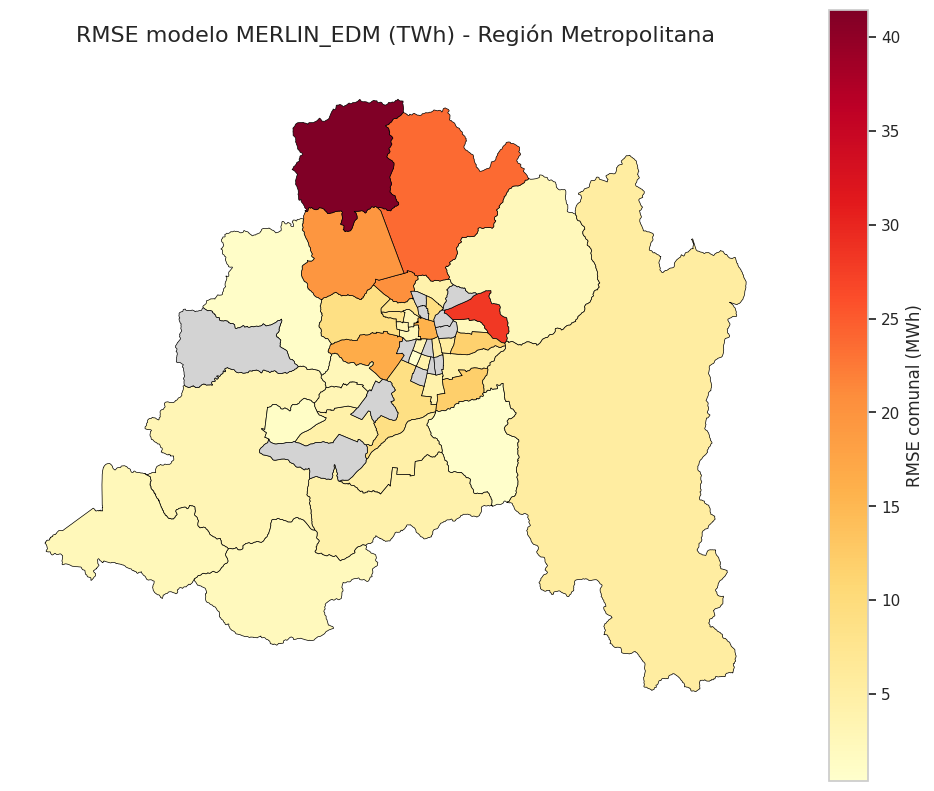

In [45]:
# 1. Filtrar el GeoDataFrame para dejar solo las 52 comunas de la RM
# Reemplaza 'region' por el nombre de tu columna y 'Región Metropolitana' por tu string/código exacto.
gdf_rm = gdf_mapa[gdf_mapa['region'] == 'METROPOLITANA DE SANTIAGO']

# 2. Configurar la figura (proporción más cuadrada para la RM)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 3. Graficar la geocapa de la Región Metropolitana
gdf_rm.plot(column='RMSE', 
            ax=ax, 
            legend=True,
            cmap='YlOrRd', 
            legend_kwds={
                'label': "RMSE comunal (MWh)", 
                'shrink': 0.8,       # Una barra un poco más alta se ve bien aquí
                'orientation': "vertical"
            },
            missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
            edgecolor='black',
            linewidth=0.5) # Aumentamos levemente el grosor de línea porque es un mapa con "zoom"

# 4. Detalles estéticos
plt.title('RMSE modelo MERLIN_EDM (TWh) - Región Metropolitana', fontsize=16, pad=20)
ax.set_axis_off() 
plt.tight_layout()
plt.show()